---

# 0. Preparação

In [128]:
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [129]:
df=pd.read_csv('sleep_mobile_stress_dataset_15000.csv')
df.describe()

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


In [130]:
# Variáveis categóricas: OneHotEncoder porque nem occupation nem gender têm uma ordem natural
categorical_columns = ['occupation', 'gender']
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[categorical_columns])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

data = pd.concat([df, one_hot_df], axis=1)
data = data.drop(['occupation', 'gender'], axis=1)

1. Carregar dataset
2. Encoding<br>
[
3. K-means k=2/5/10 no stress_level
4. Dropar user_id
5. Train/test split com stratify=y
6. StandardScaler (fit apenas no X_train)
7. Optuna com cross-validation no X_train
8. Treinar modelo final com melhores hiperparâmetros
9. Avaliar UMA VEZ no X_test<br>
]

---

# 1. Divisão do Stress Level

### 1.1 K-Means

In [131]:
#K-Means
def apply_kmeans(df, k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df[['stress_level']])
    
    centroids = kmeans.cluster_centers_.flatten()
    order = centroids.argsort()
    label_map = {order[i]: i for i in range(k)}
    
    labels = pd.Series(kmeans.labels_).map(label_map)
    return labels, sorted(centroids)

df['stress_2class_km'],  centroids_2  = apply_kmeans(df, 2)
df['stress_5class_km'],  centroids_5  = apply_kmeans(df, 5)
df['stress_10class_km'], centroids_10 = apply_kmeans(df, 10)

for k, col_km, centroids in [
    (2,  'stress_2class_km',  centroids_2),
    (5,  'stress_5class_km',  centroids_5),
    (10, 'stress_10class_km', centroids_10),
]:
    print(f"{k} classes:")
    print(f"Centroides: {[round(c, 2) for c in centroids]}")
    km_ranges = df.groupby(col_km)['stress_level'].agg(['min', 'max', 'count'])
    print(km_ranges)
    print()

2 classes:
Centroides: [np.float64(4.21), np.float64(9.08)]
                   min    max  count
stress_2class_km                    
0                 1.00   6.64   6451
1                 6.65  10.00   8549

5 classes:
Centroides: [np.float64(2.0), np.float64(4.07), np.float64(5.97), np.float64(7.89), np.float64(9.83)]
                   min    max  count
stress_5class_km                    
0                 1.00   3.03   1582
1                 3.04   5.01   2552
2                 5.02   6.93   2688
3                 6.94   8.86   2776
4                 8.87  10.00   5402

10 classes:
Centroides: [np.float64(1.36), np.float64(2.58), np.float64(3.6), np.float64(4.56), np.float64(5.47), np.float64(6.36), np.float64(7.26), np.float64(8.16), np.float64(9.03), np.float64(9.96)]
                    min    max  count
stress_10class_km                    
0                  1.00   1.97    706
1                  1.98   3.08    928
2                  3.09   4.08   1194
3                  4.09 

### 1.2 Equal-Frequency Binning

In [132]:
# Equal-Frequency Binning
df['stress_2class']  = pd.qcut(df['stress_level'], q=2,  labels=[0,1])
#df['stress_5class']  = pd.qcut(df['stress_level'], q=5,  labels=[0,1,2,3,4])               <- ERRO: "Bin edges must be unique: Index([1.0, 4.22, 6.34, 8.46, 10.0, 10.0]"
#df['stress_10class'] = pd.qcut(df['stress_level'], q=10, labels=[0,1,2,3,4,5,6,7,8,9])     <- ERRO: "Bin edges must be unique: Index([1.0, 2.94, 4.22, 5.29, 6.34, 7.38, 8.46, 9.52, 10.0, 10.0, 10.0]"
    
    #solução possível: dropar duplicates. mas isso faria: na divisão de 5 ficarmos com 4 labels e na divisão de 10 ficarmos com 8 labels
        #portanto: inviável.

In [133]:
print("2 classes:")
print(df['stress_2class'].value_counts().sort_index())
print("\nRanges:")
print(pd.qcut(df['stress_level'], q=2).value_counts().sort_index())

2 classes:
stress_2class
0    7504
1    7496
Name: count, dtype: int64

Ranges:
stress_level
(0.999, 7.38]    7504
(7.38, 10.0]     7496
Name: count, dtype: int64


Relativamente ao bloco de código de cima (Equal-Frequency Binning):
- Para o Problema C (10 classes), a abordagem inicial foi usar equal-frequency binning com pd.qcut(q=10), que divide os dados em 10 grupos com aproximadamente 10% da população cada (~1500 instâncias por classe). O objectivo era garantir classes equilibradas para o treino dos modelos.
- O método falhou com um ValueError indicando que os limites dos bins não são únicos. Concretamente, os percentis 80%, 90% e 100% coincidem todos no valor 10.0:
Index([1.0, 2.94, 4.22, 5.29, 6.34, 7.38, 8.46, 9.52, 10.0, 10.0, 10.0])
- A distribuição do stress_level é fortemente assimétrica, com aproximadamente 30% dos dados concentrados no valor máximo (10.0). Isso significa que os três últimos decis — que deveriam corresponder a classes distintas — têm todos o mesmo limite superior de 10.0, tornando impossível distingui-los como intervalos separados.
- Esta falha é em si um achado relevante sobre os dados: a concentração no valor 10 impede uma divisão equal-frequency em 10 classes verdadeiramente distintas. A solução adoptada foi usar duplicates='drop', que descarta os bins impossíveis, resultando em menos de 10 classes — o que deve ser reportado e justificado.
- a conclusão correcta: a distribuição dos dados não permite equal-frequency puro com 5 ou 10 classes distintas. Isso não é um problema do código, é uma característica dos dados que precisam de ser reportada.
<br><br>"Tentou-se aplicar equal-frequency binning, mas a concentração de ~30% dos dados no valor máximo (10.0) impossibilita criar bins com limites únicos para 5 e 10 classes. O K-Means foi adoptado por ser robusto a esta assimetria."

---

# 2. Cenário A - Classificação Binária

## 2.1. Treino/Teste e Scale

In [134]:
# Copiar os targets de df para data
for col in ['stress_2class_km']:
    data[col] = df[col].values
    
y = data['stress_2class_km']
X = data.drop(['stress_level', 'stress_2class_km', 'user_id'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [135]:
scaler = StandardScaler()
columns_to_scale = [
    'age',
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'sleep_duration_hours',
    'sleep_quality_score',
    'caffeine_intake_cups',
    'physical_activity_minutes',
    'notifications_received_per_day',
    'mental_fatigue_score'
]

X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

# print("X_train head after scaling:")
# print(X_train.head())
# print(X_train.shape)

## 2.2 NN

In [136]:
def objective(trial):
    # Otimizar a arquitetura da rede (número de camadas e neurónios)
    n_layers = trial.suggest_int("n_layers", 1, 3)
    
    hidden_layers = []
    for i in range(n_layers):
        hidden_layers.append(trial.suggest_int(f"n_units_l{i}", 4, 128))
        
    # Otimizar a taxa de aprendizagem
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)

    # Definir o modelo de Rede Neural do Scikit-Learn
    model = MLPClassifier(
        hidden_layer_sizes=tuple(hidden_layers),
        learning_rate_init=lr,
        max_iter=2, #claude diz: mto pouco, minimo 200
        random_state=42,
        early_stopping=True # Previne overfitting parando o treino se a métrica não melhorar
    )

    # Treinar o modelo
    model.fit(X_train, y_train)
    
    # Fazer previsões no set de teste
    y_pred = model.predict(X_test)
    
    # Calcular e retornar o Accuracy (Optuna vai tentar maximizar este valor)
    # Nota by chatgpt: No original maximizavas o erro de treino (correct_train / total_train), o que pode causar overfitting. O correto é usar o teste: X_test / y_test
        #Nota2 by Claude: O chatgpt usou X_test/y_test, ou seja, escolher os hiperparâmetros com base no conjunto de teste. O correcto é usar um conjunto de validação separado, ou cross-validation dentro do objective
        #"Claude diz: "Estão a optimizar accuracy_score. Com 73%/27% de desequilíbrio, um modelo que classifique tudo como "stressado" já tem ~73% de accuracy sem aprender nada. Devem optimizar F1 (ou AUC-ROC), como tinham planeado.""
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='f1') #<- f1
    
    return scores.mean()

# Executar o estudo do Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=2) #claude diz: mto pouco, pelo menos 50-100
trial = study.best_trial

print(f"\nMelhor F1 no Teste: {trial.value:.4f}")
print("Melhores Hiperparâmetros encontrados:", trial.params)

[I 2026-05-16 19:17:48,768] A new study created in memory with name: no-name-82a25a1c-b8dd-4b8e-98fd-23d62e91cd44
c:\Users\ruizi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ruizi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ruizi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ruizi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilaye


Melhor F1 no Teste: 0.9470
Melhores Hiperparâmetros encontrados: {'n_layers': 2, 'n_units_l0': 104, 'n_units_l1': 68, 'lr': 0.04038868655402702}


In [137]:
#fazer pip install nbformat

# Gráfico com o histórico da otimização
fig1 = optuna.visualization.plot_optimization_history(study)
fig1.show()

# Gráfico detalhando o impacto de cada hiperparâmetro
fig2 = optuna.visualization.plot_slice(study)
fig2.show()

## 2.3. SVM

In [138]:
def objective_svm(trial):
    kernel = trial.suggest_categorical('kernel', ['rbf', 'linear', 'poly'])
    C = trial.suggest_float('C', 1e-2, 1e2, log=True)
    
    if kernel == 'rbf':
        gamma = trial.suggest_float('gamma', 1e-4, 1e0, log=True)
        model = SVC(kernel=kernel, C=C, gamma=gamma, random_state=42)
    elif kernel == 'poly':
        gamma = trial.suggest_float('gamma', 1e-4, 1e0, log=True)
        degree = trial.suggest_int('degree', 2, 4)
        model = SVC(kernel=kernel, C=C, gamma=gamma, degree=degree, random_state=42)
    else:  # linear
        model = SVC(kernel=kernel, C=C, random_state=42)

    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='f1')
    return scores.mean()

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=2) #mudar os trials, é pouco
best_svm = study_svm.best_trial

print(f"\nMelhor F1 (cross-validation): {best_svm.value:.4f}")
print("Melhores Hiperparâmetros:", best_svm.params)

# Treinar modelo final com os melhores hiperparâmetros e avaliar no teste
params = best_svm.params
if params['kernel'] == 'rbf':
    final_svm = SVC(kernel=params['kernel'], C=params['C'], gamma=params['gamma'], random_state=42)
elif params['kernel'] == 'poly':
    final_svm = SVC(kernel=params['kernel'], C=params['C'], gamma=params['gamma'], degree=params['degree'], random_state=42)
else:
    final_svm = SVC(kernel=params['kernel'], C=params['C'], random_state=42)

final_svm.fit(X_train, y_train)
y_pred_svm = final_svm.predict(X_test)
print(f"\nF1 no Teste: {f1_score(y_test, y_pred_svm):.4f}")

[I 2026-05-16 19:17:49,555] A new study created in memory with name: no-name-7901567e-1806-4bf2-a156-4ab937df88b1
[I 2026-05-16 19:17:53,397] Trial 0 finished with value: 0.7292676006875425 and parameters: {'kernel': 'poly', 'C': 1.2233859126518685, 'gamma': 0.003283194724057219, 'degree': 2}. Best is trial 0 with value: 0.7292676006875425.
[I 2026-05-16 19:17:56,103] Trial 1 finished with value: 0.9532776952977119 and parameters: {'kernel': 'rbf', 'C': 0.021784300754037873, 'gamma': 0.06489539526577165}. Best is trial 1 with value: 0.9532776952977119.



Melhor F1 (cross-validation): 0.9533
Melhores Hiperparâmetros: {'kernel': 'rbf', 'C': 0.021784300754037873, 'gamma': 0.06489539526577165}

F1 no Teste: 0.9550


## 2.4. Terceiro Método

### 2.4.1. Random Forest

[I 2026-05-16 19:19:04,124] A new study created in memory with name: no-name-0d109a62-bbb1-41aa-80eb-ea0ac971957d
[I 2026-05-16 19:19:08,919] Trial 0 finished with value: 0.9443001112265357 and parameters: {'n_estimators': 220, 'max_depth': 3, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None}. Best is trial 0 with value: 0.9443001112265357.
[I 2026-05-16 19:19:12,900] Trial 1 finished with value: 0.9499220275332328 and parameters: {'n_estimators': 237, 'max_depth': 17, 'min_samples_split': 20, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9499220275332328.



Melhor F1 (cross-validation): 0.9499
Melhores Hiperparâmetros: {'n_estimators': 237, 'max_depth': 17, 'min_samples_split': 20, 'min_samples_leaf': 3, 'max_features': 'sqrt'}

F1 no Teste: 0.9545


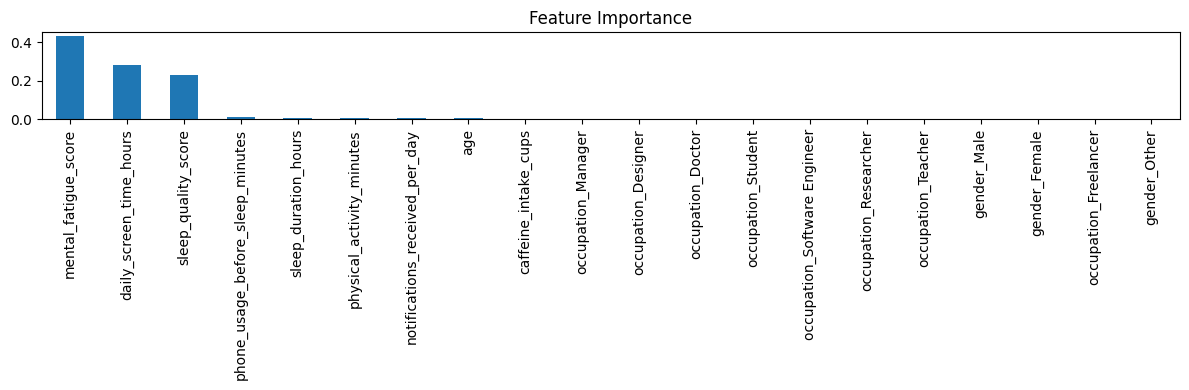

In [140]:
def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight='balanced',
        random_state=42
    )

    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='f1')
    return scores.mean()

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=2) #é pouco, mudar
best_rf = study_rf.best_trial

print(f"\nMelhor F1 (cross-validation): {best_rf.value:.4f}")
print("Melhores Hiperparâmetros:", best_rf.params)

# Treinar modelo final e avaliar no teste
final_rf = RandomForestClassifier(
    **best_rf.params,
    class_weight='balanced',
    random_state=42
)
final_rf.fit(X_train, y_train)
y_pred_rf = final_rf.predict(X_test)
print(f"\nF1 no Teste: {f1_score(y_test, y_pred_rf):.4f}")

# Feature importance
importances = pd.Series(final_rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(12, 4), title='Feature Importance')
plt.tight_layout()
plt.show()

### 2.4.2. ...

# Cenário 2 - 5 Classes

# Cenário 3 - 10 Classes